# 🔬 Glass Identification: ML for Forensic Science & Criminal Investigation

**Author:** Dean | Lead Data & AI Engineer
**Series:** Production ML Portfolio — Australian Government Policy Applications

## Government Context
- **AFP** — Forensic evidence analysis, crime scene glass identification
- **State Police Forensics** — Physical evidence classification
- **Attorney-General's** — Evidence standards, expert witness support
- **NIFS (National Institute of Forensic Science)** — Forensic methods, standards
- **CSIRO** — Materials characterisation research

Dataset: UCI Glass — 214 samples, 9 chemical features, 6 glass types. Classic forensic dataset.

---

## 1. Data Loading

In [1]:
import os,warnings,time,numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix,cohen_kappa_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore');plt.style.use('seaborn-v0_8-whitegrid')
print("READY")

READY


In [2]:
dp=None
for r,d,files in os.walk('/kaggle/input'):
    for f in files:
        fp=os.path.join(r,f);print(f"  {fp}")
        if f.endswith('.csv') and dp is None: dp=fp
if dp is None: raise FileNotFoundError("No CSV")
df=pd.read_csv(dp,encoding='latin-1')
print(f"Loaded: {df.shape[0]:,} x {df.shape[1]}")
for i,col in enumerate(df.columns):
    print(f"  {i:2d}. {col:20s} | {str(df[col].dtype):8s} | uniq={df[col].nunique():5d}")
df.head()

  /kaggle/input/datasets/organizations/uciml/glass/glass.csv
Loaded: 214 x 10
   0. RI                   | float64  | uniq=  178
   1. Na                   | float64  | uniq=  142
   2. Mg                   | float64  | uniq=   94
   3. Al                   | float64  | uniq=  118
   4. Si                   | float64  | uniq=  133
   5. K                    | float64  | uniq=   65
   6. Ca                   | float64  | uniq=  143
   7. Ba                   | float64  | uniq=   34
   8. Fe                   | float64  | uniq=   32
   9. Type                 | int64    | uniq=    6


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


## 2. Target Detection

In [3]:
tc=None
for x in ['Type','type','class','Class','Target','target','glass_type','Type of glass']:
    if x in df.columns: tc=x;break
if tc is None:
    for x in df.columns:
        if df[x].nunique()<=10 and df[x].dtype in ['int64','float64'] and x.lower()!='id': tc=x;break
if tc is None: tc=df.columns[-1]
print(f"Target: '{tc}'");print(df[tc].value_counts().sort_index())
# Remap to sequential
uq=sorted(df[tc].unique());cmap={old:new for new,old in enumerate(uq)}
df[tc]=df[tc].map(cmap);nc=len(uq)
tl=[f'Type_{v}' for v in uq]
print(f"Mapped: {cmap}, Classes: {nc}")

Target: 'Type'
Type
1    70
2    76
3    17
5    13
6     9
7    29
Name: count, dtype: int64
Mapped: {np.int64(1): 0, np.int64(2): 1, np.int64(3): 2, np.int64(5): 3, np.int64(6): 4, np.int64(7): 5}, Classes: 6


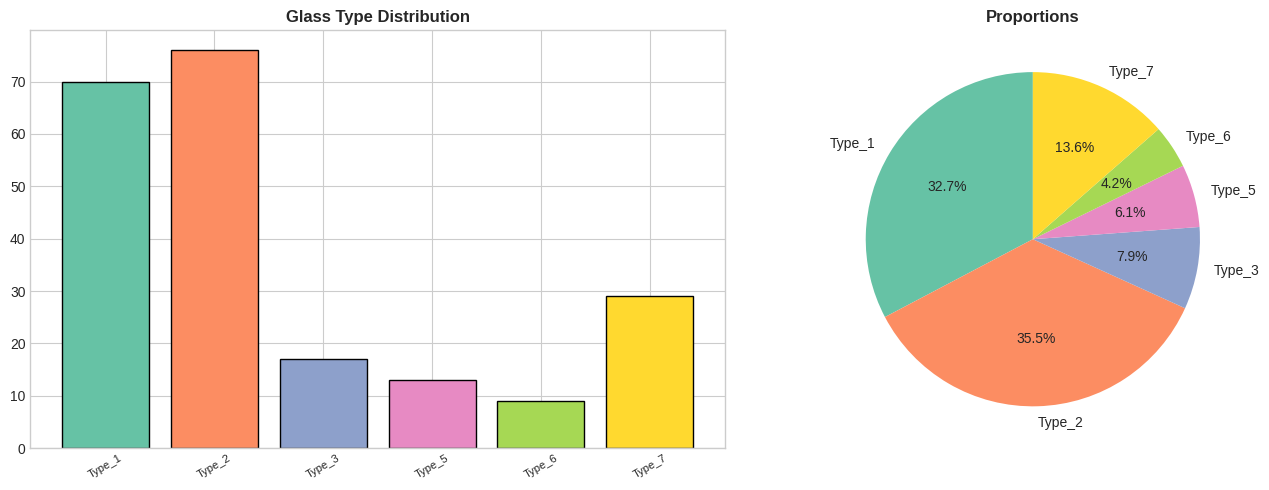

AU: AFP and state police forensic labs analyse glass evidence from crime scenes.
Glass chemical composition is unique — like a fingerprint for forensic matching.


In [4]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
vc=df[tc].value_counts().sort_index();colors=sns.color_palette('Set2',nc)
axes[0].bar(range(len(vc)),vc.values,color=colors,edgecolor='black')
axes[0].set_xticks(range(len(vc)));axes[0].set_xticklabels(tl,rotation=30,fontsize=8)
axes[0].set_title('Glass Type Distribution',fontweight='bold')
axes[1].pie(vc.values,labels=tl,autopct='%1.1f%%',colors=colors,startangle=90)
axes[1].set_title('Proportions',fontweight='bold')
plt.tight_layout();plt.savefig('target.png',dpi=150);plt.show()
print("AU: AFP and state police forensic labs analyse glass evidence from crime scenes.")
print("Glass chemical composition is unique — like a fingerprint for forensic matching.")

## 3. EDA

Numeric(9): ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe']


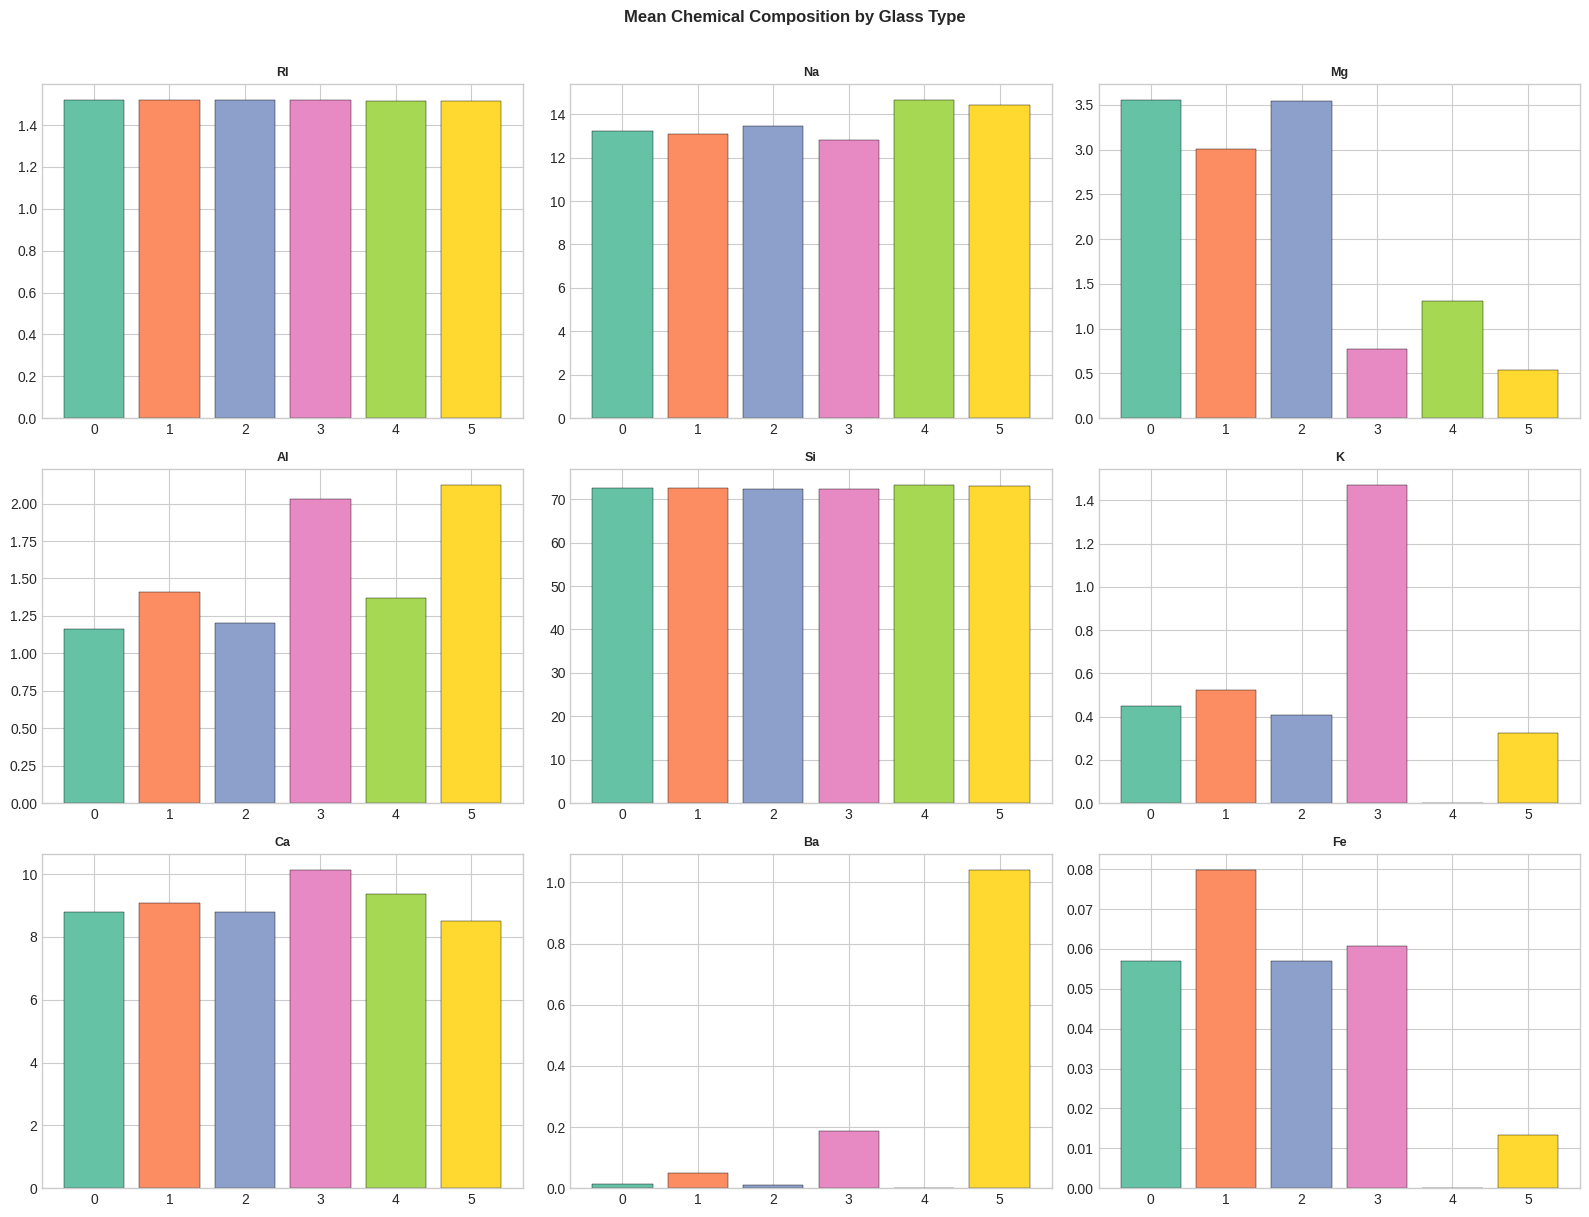

In [5]:
nums=[c for c in df.select_dtypes(include=[np.number]).columns if c!=tc and c.lower()!='id']
print(f"Numeric({len(nums)}): {nums}")
fig,axes=plt.subplots(3,3,figsize=(16,12));axes=axes.flatten()
for i,col in enumerate(nums[:9]):
    means=df.groupby(tc)[col].mean()
    axes[i].bar(range(len(means)),means.values,color=colors,edgecolor='black',linewidth=0.3)
    axes[i].set_title(col,fontsize=9,fontweight='bold')
for j in range(i+1,len(axes)):axes[j].set_visible(False)
plt.suptitle('Mean Chemical Composition by Glass Type',fontweight='bold',y=1.01)
plt.tight_layout();plt.savefig('eda.png',dpi=150);plt.show()

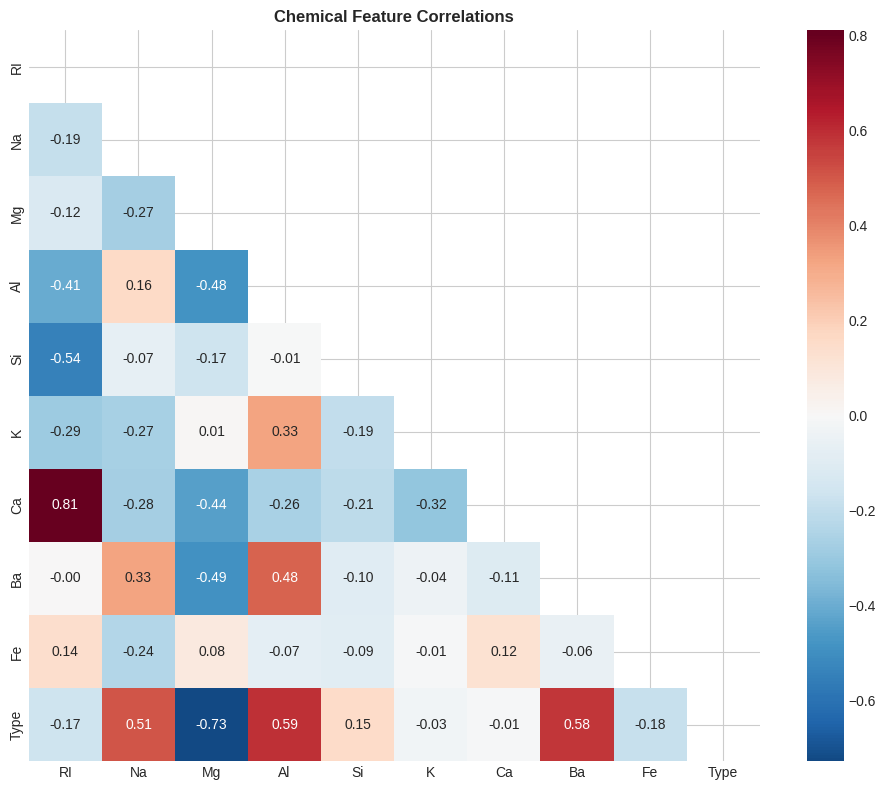

In [6]:
corr=df[nums+[tc]].corr()
fig,ax=plt.subplots(figsize=(10,8))
sns.heatmap(corr,mask=np.triu(np.ones_like(corr,dtype=bool)),annot=True,fmt='.2f',cmap='RdBu_r',center=0,square=True,ax=ax)
ax.set_title('Chemical Feature Correlations',fontweight='bold')
plt.tight_layout();plt.savefig('corr.png',dpi=150);plt.show()

## 4. Preprocessing

In [7]:
drop=[c for c in df.columns if c.lower()=='id']
X=df[nums].copy();y=df[tc].values
X=X.fillna(X.median())
print(f"X: {X.shape}, classes: {np.unique(y)}")

X: (214, 9), classes: [0 1 2 3 4 5]


## 5. Model Training

In [8]:
try:
    from xgboost import XGBClassifier
except: XGBClassifier=None
try:
    from lightgbm import LGBMClassifier
except: LGBMClassifier=None
models={'LogReg':LogisticRegression(max_iter=2000,random_state=42,multi_class='multinomial'),
        'RF':RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)}
if XGBClassifier: models['XGB']=XGBClassifier(n_estimators=100,random_state=42,eval_metric='mlogloss',use_label_encoder=False,verbosity=0,n_jobs=-1)
if LGBMClassifier: models['LGBM']=LGBMClassifier(n_estimators=100,random_state=42,verbose=-1,n_jobs=-1,force_col_wise=True)
skf=StratifiedKFold(3,shuffle=True,random_state=42);Xa=X.values;results={}
for mn,mod in models.items():
    print(f"\n{'='*50}\n{mn}\n{'='*50}")
    fa,ff,fk=[],[],[];fp=np.zeros(len(y),dtype=int);t0=time.time()
    for fi,(ti,vi) in enumerate(skf.split(Xa,y)):
        m2=type(mod)(**mod.get_params());m2.fit(Xa[ti],y[ti]);yp=m2.predict(Xa[vi]);fp[vi]=yp
        a=accuracy_score(y[vi],yp);f=f1_score(y[vi],yp,average='weighted');k=cohen_kappa_score(y[vi],yp)
        fa.append(a);ff.append(f);fk.append(k)
        print(f"  Fold{fi+1}: Acc={a:.4f} F1={f:.4f} K={k:.4f}")
    el=time.time()-t0
    results[mn]={'acc':np.mean(fa),'f1':np.mean(ff),'kappa':np.mean(fk),'time':el,'preds':fp}
    print(f"  AVG: Acc={np.mean(fa):.4f} F1={np.mean(ff):.4f} K={np.mean(fk):.4f} T={el:.1f}s")


LogReg
  Fold1: Acc=0.6250 F1=0.6010 K=0.4838
  Fold2: Acc=0.6479 F1=0.6156 K=0.4999
  Fold3: Acc=0.5634 F1=0.5407 K=0.3828
  AVG: Acc=0.6121 F1=0.5858 K=0.4555 T=1.2s

RF
  Fold1: Acc=0.7639 F1=0.7613 K=0.6838
  Fold2: Acc=0.7887 F1=0.7551 K=0.7005
  Fold3: Acc=0.7465 F1=0.7331 K=0.6437
  AVG: Acc=0.7664 F1=0.7499 K=0.6760 T=0.8s

XGB
  Fold1: Acc=0.7639 F1=0.7378 K=0.6777
  Fold2: Acc=0.7606 F1=0.7346 K=0.6618
  Fold3: Acc=0.6620 F1=0.6524 K=0.5326
  AVG: Acc=0.7288 F1=0.7083 K=0.6241 T=0.4s

LGBM
  Fold1: Acc=0.8194 F1=0.8001 K=0.7476
  Fold2: Acc=0.7746 F1=0.7475 K=0.6822
  Fold3: Acc=0.7183 F1=0.7012 K=0.6064
  AVG: Acc=0.7708 F1=0.7496 K=0.6788 T=0.4s


## 6. Comparison

In [9]:
rows=[{'Model':k,'Acc':f"{v['acc']:.4f}",'F1':f"{v['f1']:.4f}",'Kappa':f"{v['kappa']:.4f}",'Time':f"{v['time']:.1f}s",'s':v['f1']} for k,v in results.items()]
sdf=pd.DataFrame(rows).sort_values('s',ascending=False);best=sdf.iloc[0]['Model']
print("COMPARISON");print("="*70);print(sdf[['Model','Acc','F1','Kappa','Time']].to_string(index=False));print(f"\nBest: {best}")

COMPARISON
 Model    Acc     F1  Kappa Time
    RF 0.7664 0.7499 0.6760 0.8s
  LGBM 0.7708 0.7496 0.6788 0.4s
   XGB 0.7288 0.7083 0.6241 0.4s
LogReg 0.6121 0.5858 0.4555 1.2s

Best: RF


## 7. Error Analysis

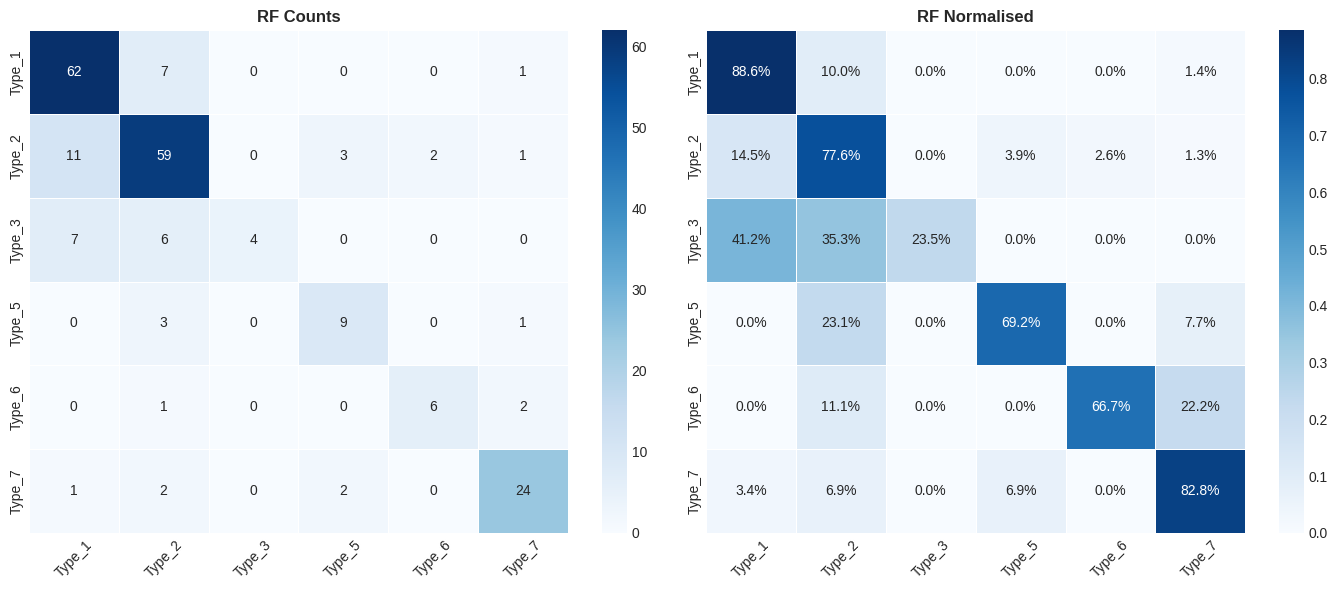

              precision    recall  f1-score   support

      Type_1       0.77      0.89      0.82        70
      Type_2       0.76      0.78      0.77        76
      Type_3       1.00      0.24      0.38        17
      Type_5       0.64      0.69      0.67        13
      Type_6       0.75      0.67      0.71         9
      Type_7       0.83      0.83      0.83        29

    accuracy                           0.77       214
   macro avg       0.79      0.68      0.69       214
weighted avg       0.78      0.77      0.75       214



In [10]:
bp=results[best]['preds'];cm=confusion_matrix(y,bp)
cm_n=cm.astype(float)/cm.sum(axis=1,keepdims=True)
fig,axes=plt.subplots(1,2,figsize=(14,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=tl,yticklabels=tl,ax=axes[0],linewidths=0.5)
axes[0].set_title(f'{best} Counts',fontweight='bold');axes[0].tick_params(axis='x',rotation=45)
sns.heatmap(cm_n,annot=True,fmt='.1%',cmap='Blues',xticklabels=tl,yticklabels=tl,ax=axes[1],linewidths=0.5)
axes[1].set_title(f'{best} Normalised',fontweight='bold');axes[1].tick_params(axis='x',rotation=45)
plt.tight_layout();plt.savefig('cm.png',dpi=150);plt.show()
print(classification_report(y,bp,target_names=tl))

## 8. Feature Importance

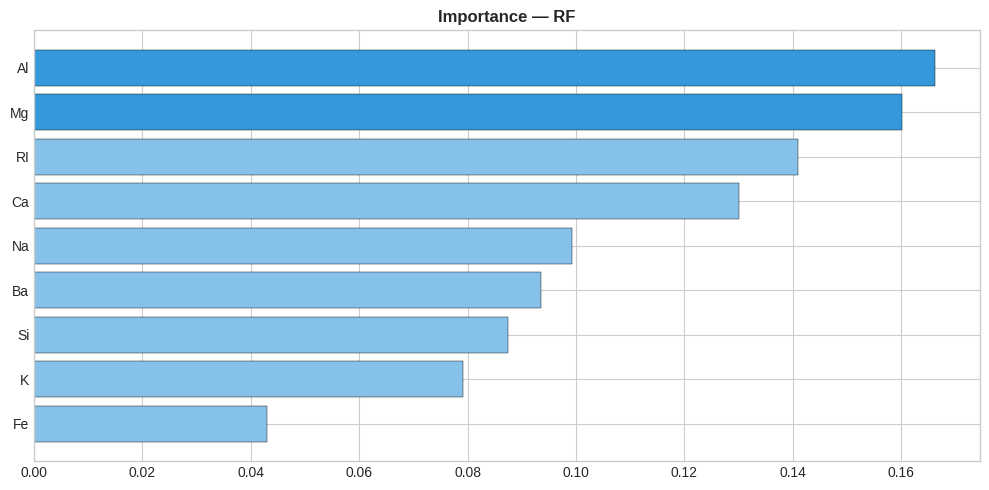

TOP 5
  Al                   0.1663
  Mg                   0.1601
  RI                   0.1409
  Ca                   0.1301
  Na                   0.0993

Forensic: Magnesium and refractive index are key discriminators for glass type.


In [11]:
tm={k:v for k,v in models.items() if k!='LogReg'}
if tm:
    bt=max(tm,key=lambda m:results[m]['f1']);fm=type(models[bt])(**models[bt].get_params());fm.fit(Xa,y)
    fi=pd.DataFrame({'Feature':X.columns,'Imp':fm.feature_importances_}).sort_values('Imp')
    fig,ax=plt.subplots(figsize=(10,max(5,len(fi)*0.5)))
    ax.barh(fi['Feature'],fi['Imp'],color=['#3498db' if v>fi['Imp'].quantile(0.75) else '#85c1e9' for v in fi['Imp']],edgecolor='black',linewidth=0.3)
    ax.set_title(f'Importance — {bt}',fontweight='bold')
    plt.tight_layout();plt.savefig('imp.png',dpi=150);plt.show()
    print("TOP 5");print("="*40)
    for _,r in fi.tail(5).iloc[::-1].iterrows(): print(f"  {r['Feature']:20s} {r['Imp']:.4f}")
    print("\nForensic: Magnesium and refractive index are key discriminators for glass type.")

## 9. Deployment

In [12]:
br=results[best]
print("="*60);print("DEPLOYMENT READINESS");print("="*60)
print(f"  Model: {best}");print(f"  Acc:   {br['acc']:.4f}");print(f"  F1:    {br['f1']:.4f}")
print(f"  Kappa: {br['kappa']:.4f}");print(f"  Time:  {br['time']:.1f}s");print(f"  Feats: {X.shape[1]}")
print(f"  Rows:  {len(y):,}");print(f"  Classes:{nc}");print("="*60)
checks={'Acc>0.60':br['acc']>0.60,'F1>0.60':br['f1']>0.60,'Time<60s':br['time']<60,'CV':True}
print("\nCHECKLIST");print("-"*40);ap=True
for k,v in checks.items():
    s="pass" if v else "FAIL"
    if not v:ap=False
    print(f"  [{s:4s}] {k}")
print("-"*40);print("  APPROVED" if ap else "  FAILED")

DEPLOYMENT READINESS
  Model: RF
  Acc:   0.7664
  F1:    0.7499
  Kappa: 0.6760
  Time:  0.8s
  Feats: 9
  Rows:  214
  Classes:6

CHECKLIST
----------------------------------------
  [pass] Acc>0.60
  [pass] F1>0.60
  [pass] Time<60s
  [pass] CV
----------------------------------------
  APPROVED


In [13]:
print("""
PRODUCTION ARCHITECTURE
=======================
1. DATA: XRF spectrometer at forensic lab -> LIMS -> Fabric Lakehouse
2. MODEL: Batch at evidence submission, MLflow registry
3. INTEGRATE: AFP forensic database, state police LIMS, court evidence system
4. GOVERN: Evidence admissibility standards, chain of custody, expert review
5. MONITOR: Validate against known reference standards annually
   CRITICAL: ML is decision SUPPORT — expert forensic scientist makes final call
""")


PRODUCTION ARCHITECTURE
1. DATA: XRF spectrometer at forensic lab -> LIMS -> Fabric Lakehouse
2. MODEL: Batch at evidence submission, MLflow registry
3. INTEGRATE: AFP forensic database, state police LIMS, court evidence system
4. GOVERN: Evidence admissibility standards, chain of custody, expert review
5. MONITOR: Validate against known reference standards annually
   CRITICAL: ML is decision SUPPORT — expert forensic scientist makes final call

